In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.2)
plt.rcParams.update({
    "figure.dpi": 120,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
})

SILVER_FILE = "data/silver/silver_databridge.csv"
OUT_DIR     = "data/gold"
os.makedirs(OUT_DIR, exist_ok=True)
print("Configurações aplicadas ✅")

Configurações aplicadas ✅


In [2]:
df = pd.read_csv('../silver_layer/silver_databridge.csv')
print(f"Registros: {len(df):,} | Segmentos: {df['customer_segment'].nunique()}")
df["customer_segment"].value_counts()

Registros: 24,974 | Segmentos: 7


customer_segment
AGRO_GRANDE     3599
PJ_ME           3597
AGRO_PEQUENO    3581
PJ_GRANDE       3576
AGRO_MEDIO      3560
PJ_EPP          3549
PF              3512
Name: count, dtype: int64

C:\Users\Marce\AppData\Local\Temp\ipykernel_19328\1352235542.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=resumo, x="customer_segment", y="total",
C:\Users\Marce\AppData\Local\Temp\ipykernel_19328\1352235542.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(resumo["customer_segment"], rotation=25, ha="right")
C:\Users\Marce\AppData\Local\Temp\ipykernel_19328\1352235542.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=resumo.sort_values("valor_medio", ascending=False),
C:\Users\Marce\AppData\Local\Temp\ipykernel_19328\1352235542.py:42: UserWarning: set_ticklab

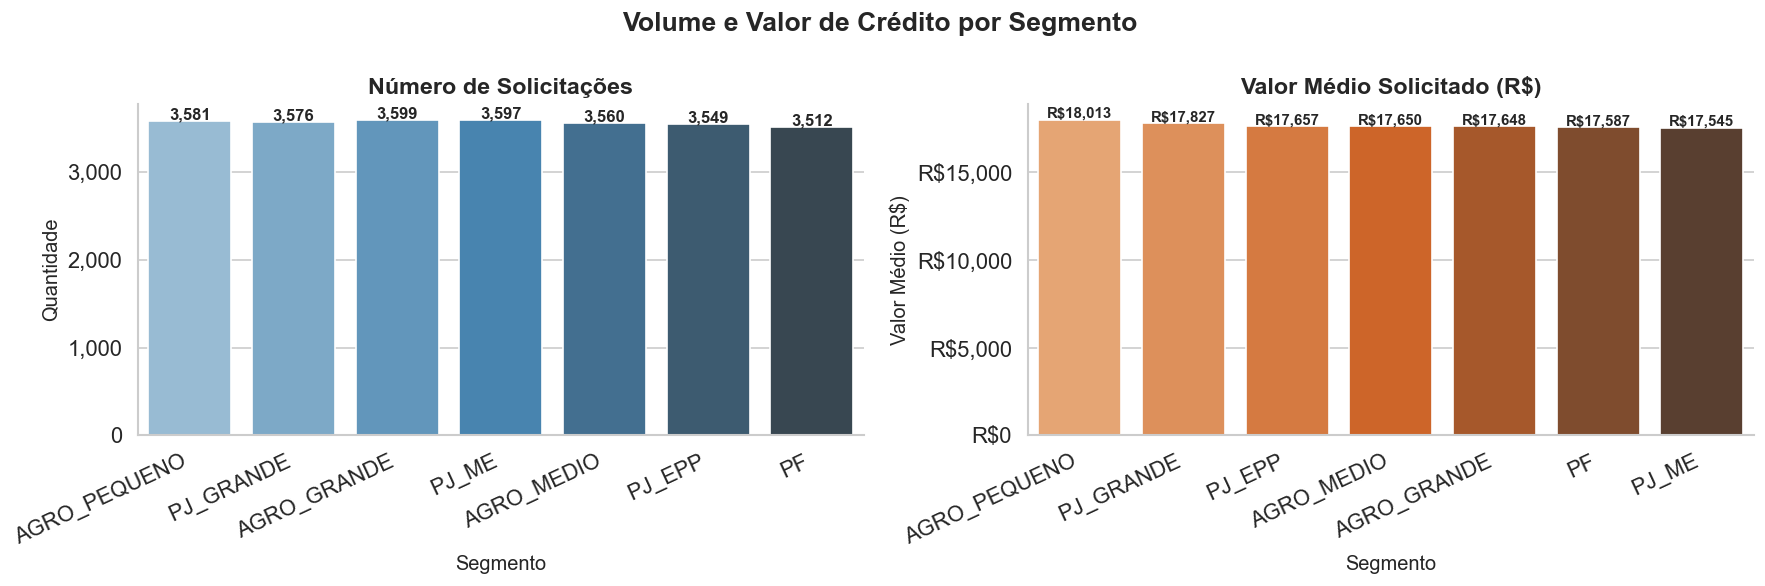

In [3]:
resumo = (
    df.groupby("customer_segment", observed=True)
    .agg(
        total               = ("default_12m", "count"),
        valor_medio         = ("credit_requested_value", "mean"),
        valor_total         = ("credit_requested_value", "sum"),
        renda_media         = ("income_declared", "mean"),
        ltv_medio           = ("ltv", "mean"),
        pd_score_medio      = ("pd_model_score", "mean"),
        default_rate        = ("default_12m", "mean"),
        pct_aprovado        = ("final_decision", lambda x: (x == "APPROVE").mean()),
    )
    .round(4)
    .reset_index()
    .sort_values("valor_total", ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Volume e Valor de Crédito por Segmento", fontsize=16, fontweight="bold")

# Volume de solicitações
sns.barplot(data=resumo, x="customer_segment", y="total",
            palette="Blues_d", ax=axes[0])
for bar, val in zip(axes[0].patches, resumo["total"]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 f"{int(val):,}", ha="center", fontsize=10, fontweight="bold")
axes[0].set_title("Número de Solicitações")
axes[0].set_xlabel("Segmento")
axes[0].set_ylabel("Quantidade")
axes[0].set_xticklabels(resumo["customer_segment"], rotation=25, ha="right")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# Valor médio solicitado
sns.barplot(data=resumo.sort_values("valor_medio", ascending=False),
            x="customer_segment", y="valor_medio", palette="Oranges_d", ax=axes[1])
for bar, val in zip(axes[1].patches, resumo.sort_values("valor_medio", ascending=False)["valor_medio"]):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                 f"R${val:,.0f}", ha="center", fontsize=9, fontweight="bold")
axes[1].set_title("Valor Médio Solicitado (R$)")
axes[1].set_xlabel("Segmento")
axes[1].set_ylabel("Valor Médio (R$)")
axes[1].set_xticklabels(
    resumo.sort_values("valor_medio", ascending=False)["customer_segment"],
    rotation=25, ha="right")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"R${x:,.0f}"))

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/segmento_01_volume_valor.png", bbox_inches="tight")
plt.show()

C:\Users\Marce\AppData\Local\Temp\ipykernel_19328\455520900.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(ordem, rotation=25, ha="right")
C:\Users\Marce\AppData\Local\Temp\ipykernel_19328\455520900.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(ordem_def, rotation=25, ha="right")


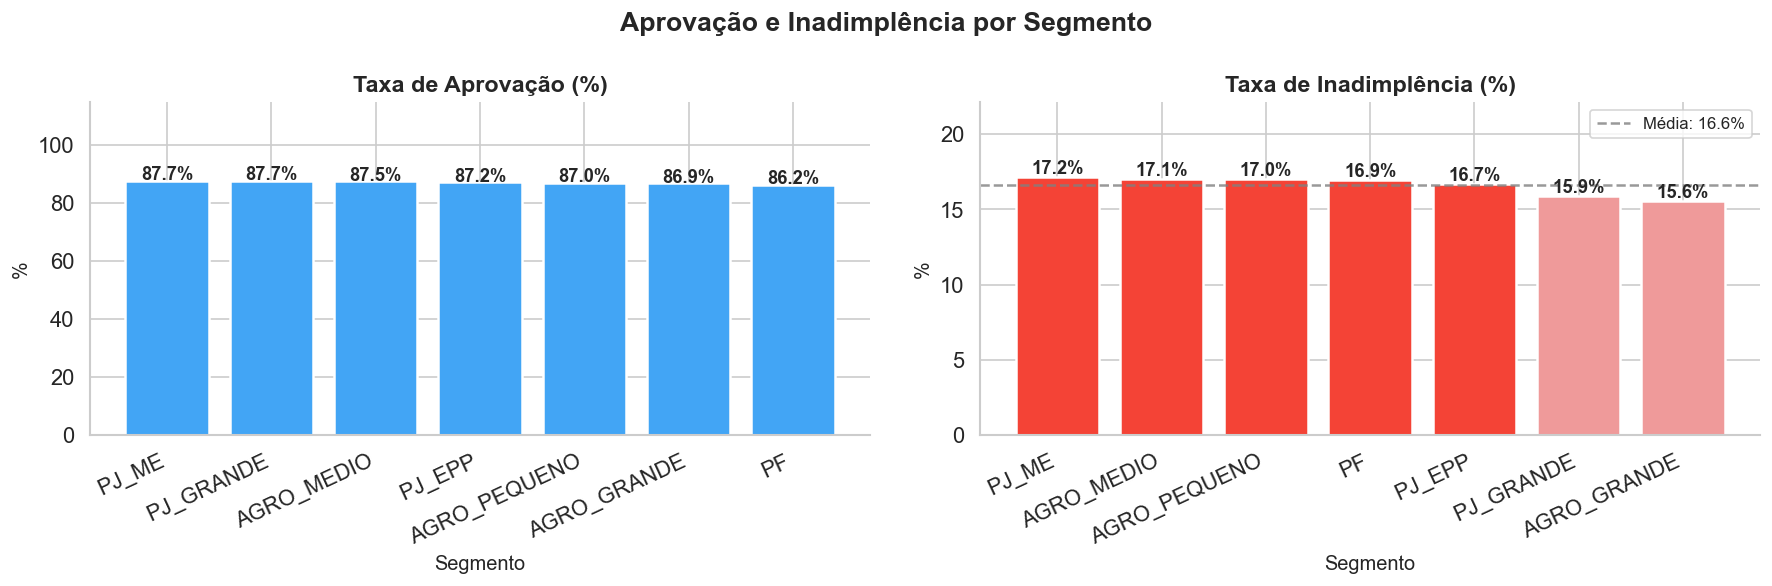

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Aprovação e Inadimplência por Segmento", fontsize=16, fontweight="bold")

ordem = resumo.sort_values("pct_aprovado", ascending=False)["customer_segment"]

# Aprovação
dados_apr = resumo.set_index("customer_segment").loc[ordem, "pct_aprovado"] * 100
bars = axes[0].bar(dados_apr.index, dados_apr.values,
                   color="#42a5f5", edgecolor="white", linewidth=1.5)
for bar, val in zip(bars, dados_apr.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f"{val:.1f}%", ha="center", fontsize=11, fontweight="bold")
axes[0].set_title("Taxa de Aprovação (%)")
axes[0].set_ylabel("%")
axes[0].set_xlabel("Segmento")
axes[0].set_xticklabels(ordem, rotation=25, ha="right")
axes[0].set_ylim(0, 115)

# Default
ordem_def = resumo.sort_values("default_rate", ascending=False)["customer_segment"]
dados_def = resumo.set_index("customer_segment").loc[ordem_def, "default_rate"] * 100
cores_def = ["#f44336" if v >= dados_def.mean() else "#ef9a9a" for v in dados_def.values]
bars = axes[1].bar(dados_def.index, dados_def.values,
                   color=cores_def, edgecolor="white", linewidth=1.5)
for bar, val in zip(bars, dados_def.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 f"{val:.1f}%", ha="center", fontsize=11, fontweight="bold")
axes[1].axhline(y=dados_def.mean(), color="gray", linestyle="--",
                alpha=0.8, label=f"Média: {dados_def.mean():.1f}%")
axes[1].set_title("Taxa de Inadimplência (%)")
axes[1].set_ylabel("%")
axes[1].set_xlabel("Segmento")
axes[1].set_xticklabels(ordem_def, rotation=25, ha="right")
axes[1].set_ylim(0, dados_def.max() + 5)
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/segmento_02_aprovacao_default.png", bbox_inches="tight")
plt.show()

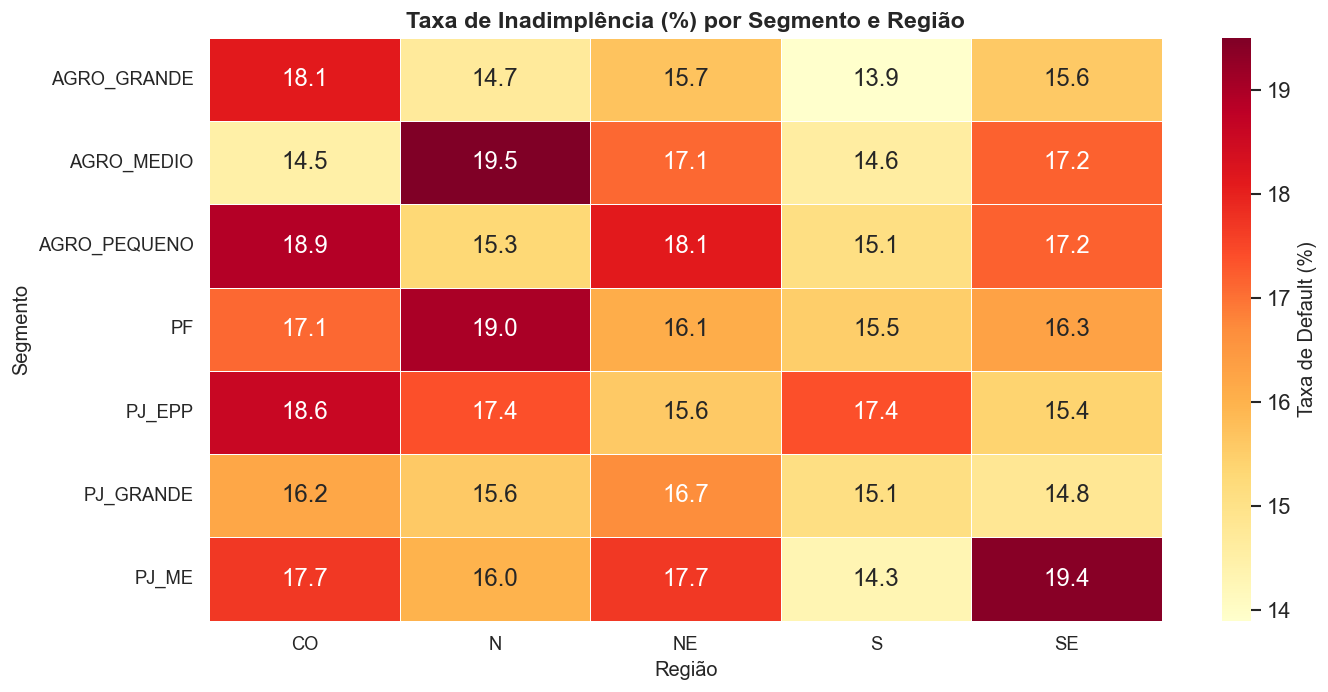

In [5]:
pivot_default = (
    df.groupby(["customer_segment", "regiao"], observed=True)["default_12m"]
    .mean()
    .unstack()
    * 100
).round(1)

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(
    pivot_default,
    annot=True, fmt=".1f", cmap="YlOrRd",
    linewidths=0.5, linecolor="white",
    cbar_kws={"label": "Taxa de Default (%)"},
    ax=ax
)
ax.set_title("Taxa de Inadimplência (%) por Segmento e Região")
ax.set_xlabel("Região")
ax.set_ylabel("Segmento")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, fontsize=11)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=11)

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/segmento_03_heatmap_default.png", bbox_inches="tight")
plt.show()

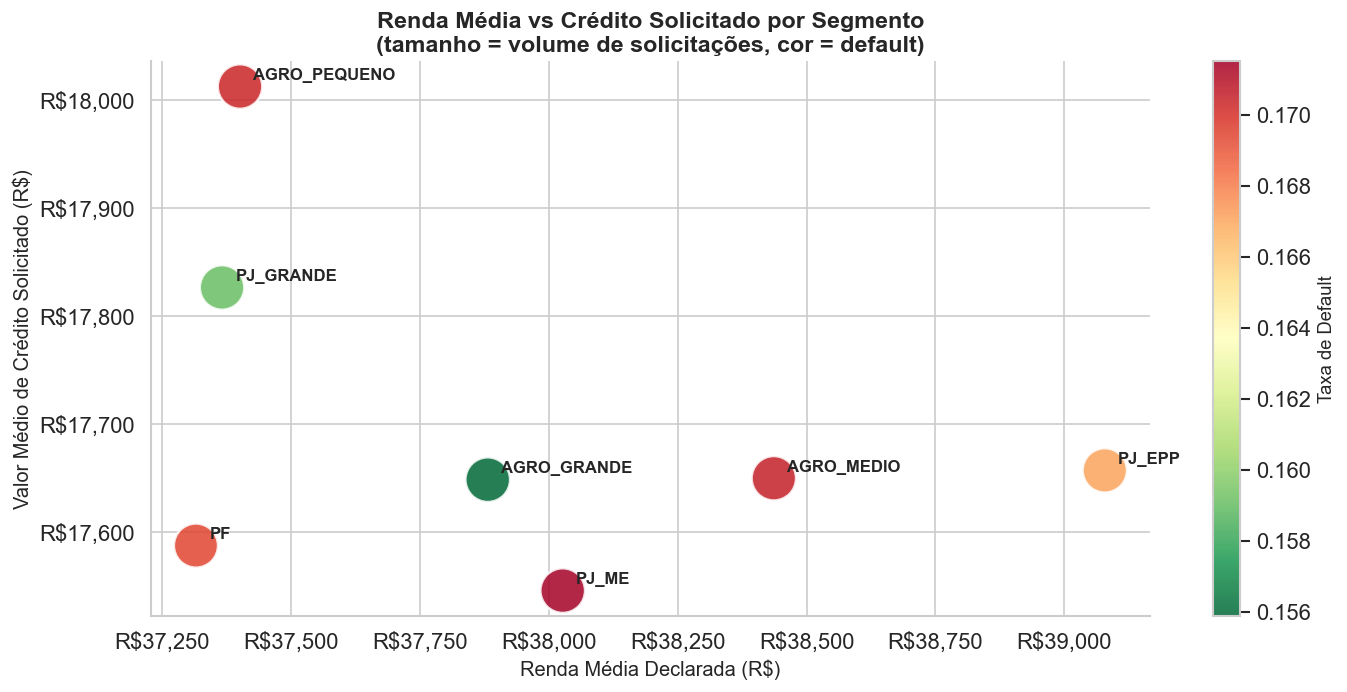

In [6]:
fig, ax = plt.subplots(figsize=(12, 6))

scatter = ax.scatter(
    resumo["renda_media"],
    resumo["valor_medio"],
    s=resumo["total"] / 5,
    c=resumo["default_rate"],
    cmap="RdYlGn_r",
    alpha=0.85,
    edgecolors="white",
    linewidth=1.5
)

for _, row in resumo.iterrows():
    ax.annotate(
        row["customer_segment"],
        (row["renda_media"], row["valor_medio"]),
        textcoords="offset points", xytext=(8, 4),
        fontsize=10, fontweight="bold"
    )

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("Taxa de Default", fontsize=11)

ax.set_title("Renda Média vs Crédito Solicitado por Segmento\n(tamanho = volume de solicitações, cor = default)")
ax.set_xlabel("Renda Média Declarada (R$)")
ax.set_ylabel("Valor Médio de Crédito Solicitado (R$)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"R${x:,.0f}"))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"R${x:,.0f}"))

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/segmento_04_renda_vs_credito.png", bbox_inches="tight")
plt.show()

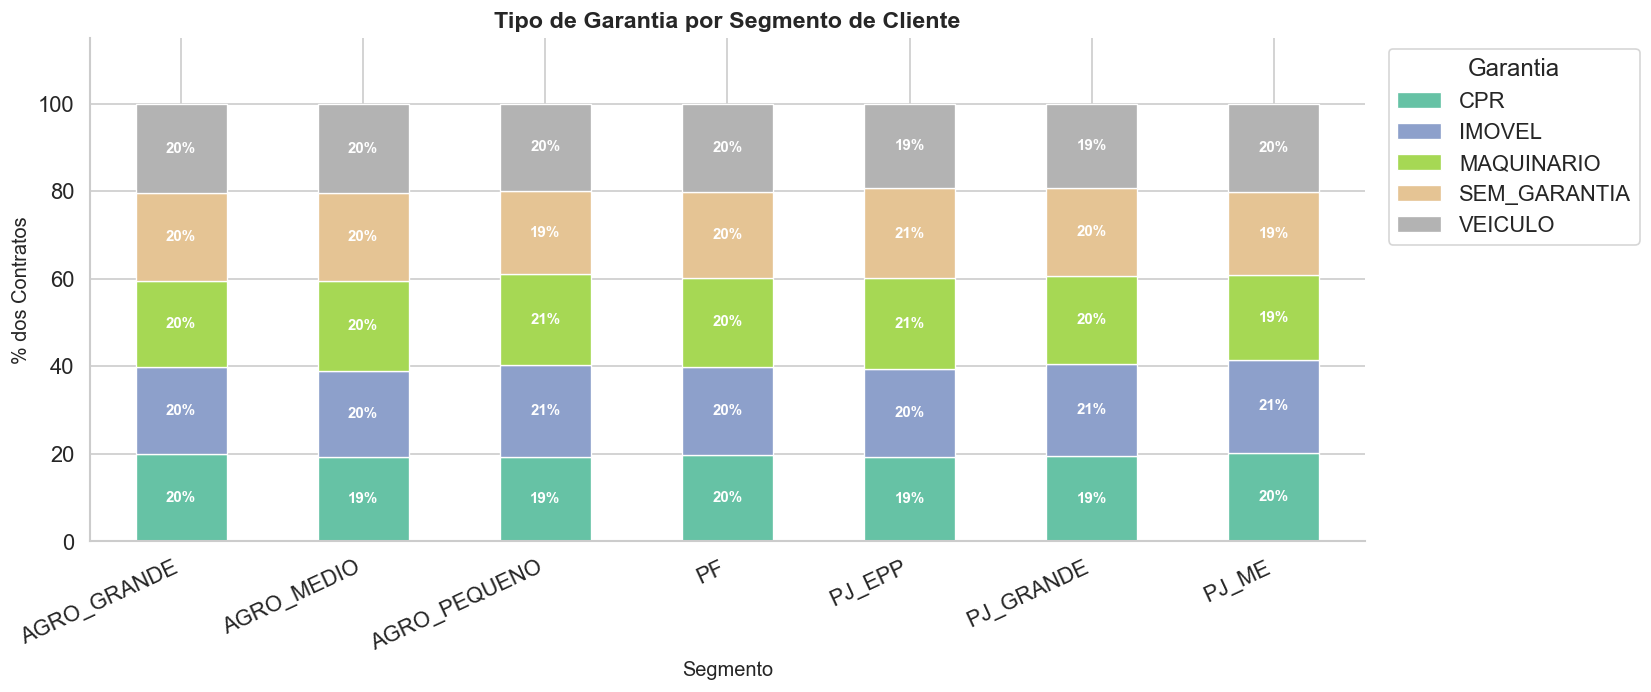

In [7]:
garantia_seg = (
    df.groupby(["customer_segment", "collateral_type"], observed=True)
    .size()
    .unstack(fill_value=0)
)
garantia_pct = garantia_seg.div(garantia_seg.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(14, 6))
garantia_pct.plot(
    kind="bar", stacked=True, ax=ax,
    colormap="Set2", edgecolor="white", linewidth=0.8
)
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f%%", label_type="center",
                 fontsize=9, fontweight="bold", color="white")

ax.set_title("Tipo de Garantia por Segmento de Cliente")
ax.set_ylabel("% dos Contratos")
ax.set_xlabel("Segmento")
ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha="right")
ax.legend(title="Garantia", bbox_to_anchor=(1.01, 1), loc="upper left")
ax.set_ylim(0, 115)

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/segmento_05_garantia.png", bbox_inches="tight")
plt.show()